# S6E7 - Predicting Student Health Risk

Goal: predict `health_condition` for the July Playground competition using a compact, interview-friendly workflow.

Plan:
1. ETL and data checks
2. Focused EDA
3. Baseline model (Logistic Regression)
4. Better model (LightGBM)
5. Kaggle-ready submission

## 1) Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

import lightgbm as lgb

warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

print("Libraries loaded.")

Libraries loaded.


## 2) ETL: Load Data

In [2]:
# Environment-aware path switching for local dev vs Kaggle
is_kaggle = os.path.exists("/kaggle/input")
input_dir = "/kaggle/input/competitions/playground-series-s6e7" if is_kaggle else "./data"
output_dir = "/kaggle/working" if os.path.exists("/kaggle/working") else "./submissions"
os.makedirs(output_dir, exist_ok=True)

train_df = pd.read_csv(os.path.join(input_dir, "train.csv"))
test_df = pd.read_csv(os.path.join(input_dir, "test.csv"))
sample_sub = pd.read_csv(os.path.join(input_dir, "sample_submission.csv"))

TARGET = "health_condition"
ID_COL = "id"

print(f"Input dir : {input_dir}")
print(f"Output dir: {output_dir}")
print(f"Train shape: {train_df.shape}")
print(f"Test shape : {test_df.shape}")
display(train_df.head(5))

Input dir : /kaggle/input/competitions/playground-series-s6e7
Output dir: /kaggle/working
Train shape: (690088, 15)
Test shape : (295753, 14)


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [3]:
# ── Quick data quality checks ──────────────────────────────────────────
print("=== Missing values (train) ===")
print(train_df.isna().sum())
print(f"\nTotal missing (train): {train_df.isna().sum().sum()}")
print(f"Total missing (test) : {test_df.isna().sum().sum()}")
print(f"\nDuplicate ids (train): {train_df[ID_COL].duplicated().sum()}")
print(f"Duplicate ids (test) : {test_df[ID_COL].duplicated().sum()}")

print("\n=== Target distribution ===")
print(train_df[TARGET].value_counts())
print("\nTarget ratios:")
print(train_df[TARGET].value_counts(normalize=True).round(4))

=== Missing values (train) ===
id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

Total missing (train): 449496
Total missing (test) : 192642

Duplicate ids (train): 0
Duplicate ids (test) : 0

=== Target distribution ===
health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64

Target ratios:
health_condition
at-risk      0.8587
unhealthy    0.0836
fit          0.0577
Name: proportion, dtype: float64


## 3) EDA

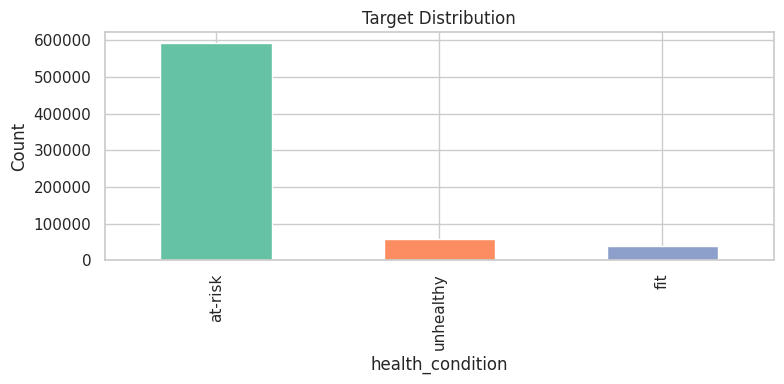

In [4]:
# ── 3a. Target distribution ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
train_df[TARGET].value_counts().plot(kind="bar", ax=ax, color=sns.color_palette("Set2"))
ax.set_title("Target Distribution")
ax.set_xlabel(TARGET)
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

Numeric features (7): ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']
Categorical features (6): ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']


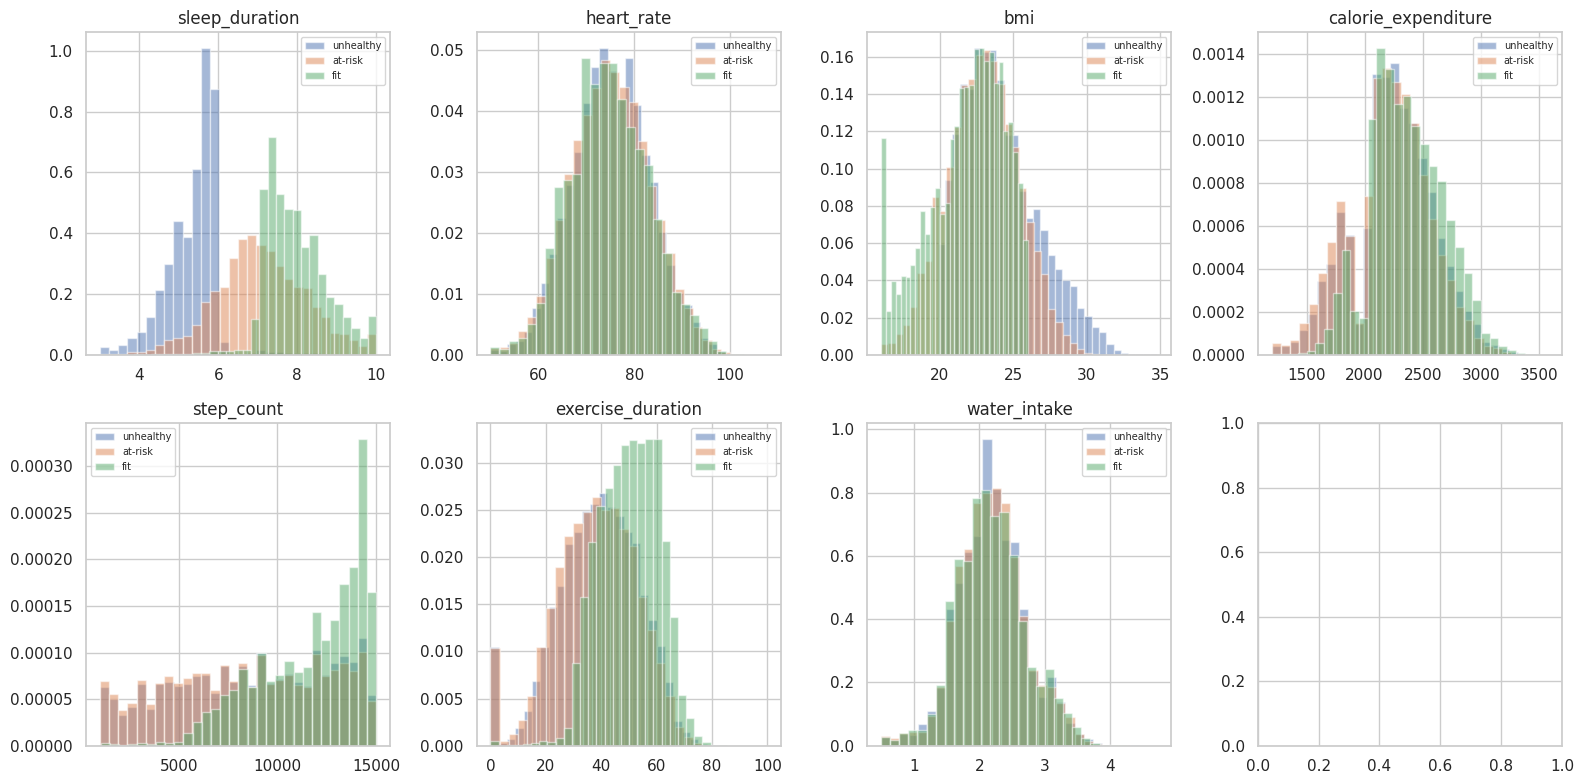

In [5]:
# ── 3b. Numeric feature distributions by target ──────────────────────
num_features = train_df.select_dtypes(include=[np.number]).columns.drop(ID_COL).tolist()
cat_features = train_df.select_dtypes(include=["object"]).columns.drop(TARGET).tolist()

print(f"Numeric features ({len(num_features)}): {num_features}")
print(f"Categorical features ({len(cat_features)}): {cat_features}")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_features[:8]):
    ax = axes[i]
    for label in train_df[TARGET].unique():
        subset = train_df[train_df[TARGET] == label][col].dropna()
        ax.hist(subset, bins=30, alpha=0.5, label=label, density=True)
    ax.set_title(col)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

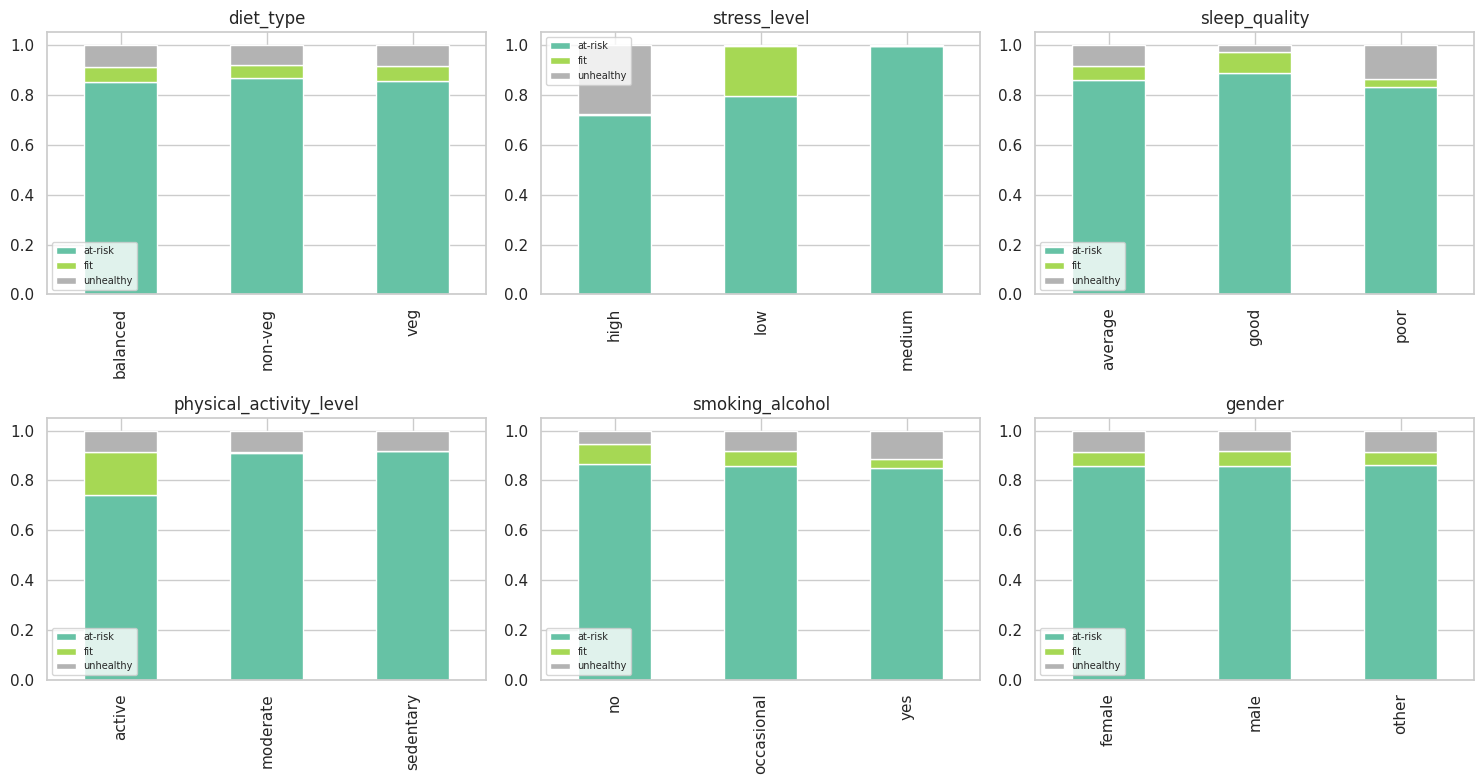

In [6]:
# ── 3c. Categorical feature breakdown by target ──────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(cat_features[:6]):
    ax = axes[i]
    ct = pd.crosstab(train_df[col], train_df[TARGET], normalize="index")
    ct.plot(kind="bar", stacked=True, ax=ax, colormap="Set2")
    ax.set_title(col)
    ax.legend(fontsize=7)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

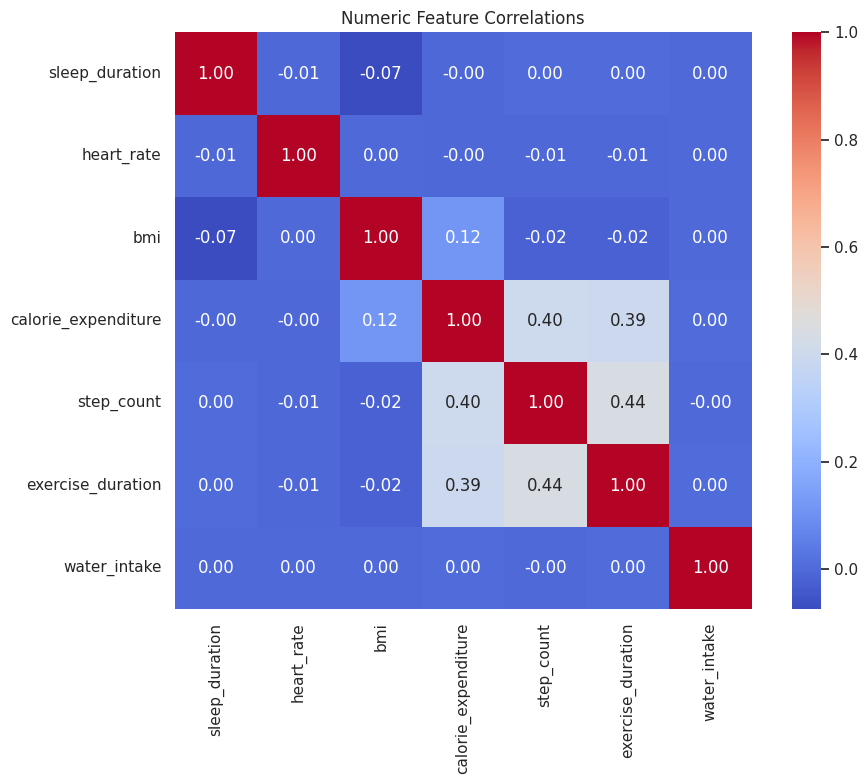

In [7]:
# ── 3d. Correlation heatmap (numeric only) ───────────────────────────
corr = train_df[num_features].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, square=True)
ax.set_title("Numeric Feature Correlations")
plt.tight_layout()
plt.show()

## 4) Feature Engineering & Preprocessing

In [8]:
def preprocess(train, test, target_col, id_col):
    """Preprocess train and test DataFrames for modeling.
    
    Steps:
    1. Separate features and target
    2. Identify numeric vs categorical columns
    3. Impute missing values (median for numeric, mode for categorical)
    4. Encode categoricals with LabelEncoder
    5. Return processed X_train, y_train, X_test, feature names, label encoder for target
    """
    # Separate target
    y = train[target_col].copy()
    X = train.drop(columns=[target_col, id_col]).copy()
    X_test = test.drop(columns=[id_col]).copy()
    
    # Identify column types
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    
    # Impute numeric: median
    for col in num_cols:
        median_val = X[col].median()
        X[col] = X[col].fillna(median_val)
        X_test[col] = X_test[col].fillna(median_val)
    
    # Impute categorical: mode
    for col in cat_cols:
        mode_val = X[col].mode()[0]
        X[col] = X[col].fillna(mode_val)
        X_test[col] = X_test[col].fillna(mode_val)
    
    # Encode categoricals
    le_dict = {}
    for col in cat_cols:
        le = LabelEncoder()
        combined = pd.concat([X[col], X_test[col]], axis=0).astype(str)
        le.fit(combined)
        X[col] = le.transform(X[col].astype(str))
        X_test[col] = le.transform(X_test[col].astype(str))
        le_dict[col] = le
    
    # Encode target
    le_target = LabelEncoder()
    y_encoded = le_target.fit_transform(y)
    
    # Safety: coerce any remaining non-numeric
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")
        X_test[col] = pd.to_numeric(X_test[col], errors="coerce")
    X = X.fillna(0)
    X_test = X_test.fillna(0)
    
    feature_names = X.columns.tolist()
    
    return X, y_encoded, X_test, feature_names, le_target, le_dict, cat_cols, num_cols


X, y, X_test, feature_names, le_target, le_dict, cat_cols, num_cols = preprocess(
    train_df, test_df, TARGET, ID_COL
)

CLASS_ORDER = list(le_target.classes_)
print(f"Classes: {CLASS_ORDER}")
print(f"X shape: {X.shape}, X_test shape: {X_test.shape}")
print(f"Features: {feature_names}")
print(f"Numeric ({len(num_cols)}): {num_cols}")
print(f"Categorical ({len(cat_cols)}): {cat_cols}")

Classes: ['at-risk', 'fit', 'unhealthy']
X shape: (690088, 13), X_test shape: (295753, 13)
Features: ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake', 'diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']
Numeric (7): ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']
Categorical (6): ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']


## 5) Baseline Model: Logistic Regression

In [9]:
# Scale for logistic regression
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# 5-fold stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr = LogisticRegression(max_iter=1000, random_state=42, multi_class="multinomial", solver="lbfgs")
lr_scores = cross_val_score(lr, X_scaled, y, cv=cv, scoring="accuracy")

print(f"Logistic Regression 5-Fold Accuracy: {lr_scores.mean():.5f} (+/- {lr_scores.std():.5f})")
print(f"Per-fold: {[f'{s:.5f}' for s in lr_scores]}")

Logistic Regression 5-Fold Accuracy: 0.90567 (+/- 0.00059)
Per-fold: ['0.90561', '0.90637', '0.90632', '0.90497', '0.90509']


In [10]:
# Fit on full train for sanity check
lr.fit(X_scaled, y)
lr_train_preds = lr.predict(X_scaled)
print(f"\nTrain accuracy (sanity check): {accuracy_score(y, lr_train_preds):.5f}")


Train accuracy (sanity check): 0.90569


## 6) Better Model: LightGBM

In [11]:
# LightGBM with 5-fold stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X))
test_preds_proba = np.zeros((len(X_test), len(CLASS_ORDER)))
fold_scores = []
feature_importances = pd.DataFrame(index=feature_names)

lgb_params = {
    "objective": "multiclass",
    "num_class": len(CLASS_ORDER),
    "metric": "multi_logloss",
    "learning_rate": 0.05,
    "num_leaves": 63,
    "max_depth": -1,
    "min_child_samples": 20,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "random_state": 42,
    "n_estimators": 1000,
    "verbosity": -1,
}

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]
    
    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
    )
    
    val_pred = model.predict(X_val)
    oof_preds[val_idx] = val_pred
    
    fold_acc = accuracy_score(y_val, val_pred)
    fold_scores.append(fold_acc)
    
    test_preds_proba += model.predict_proba(X_test) / cv.n_splits
    feature_importances[f"fold_{fold}"] = model.feature_importances_
    
    print(f"  Fold {fold}: Accuracy = {fold_acc:.5f} | Best iter = {model.best_iteration_}")

oof_acc = accuracy_score(y, oof_preds)
print(f"\nLightGBM OOF Accuracy: {oof_acc:.5f}")
print(f"Mean fold accuracy: {np.mean(fold_scores):.5f} (+/- {np.std(fold_scores):.5f})")

  Fold 1: Accuracy = 0.96519 | Best iter = 268
  Fold 2: Accuracy = 0.96583 | Best iter = 303
  Fold 3: Accuracy = 0.96559 | Best iter = 307
  Fold 4: Accuracy = 0.96542 | Best iter = 265
  Fold 5: Accuracy = 0.96509 | Best iter = 297

LightGBM OOF Accuracy: 0.96542
Mean fold accuracy: 0.96542 (+/- 0.00027)


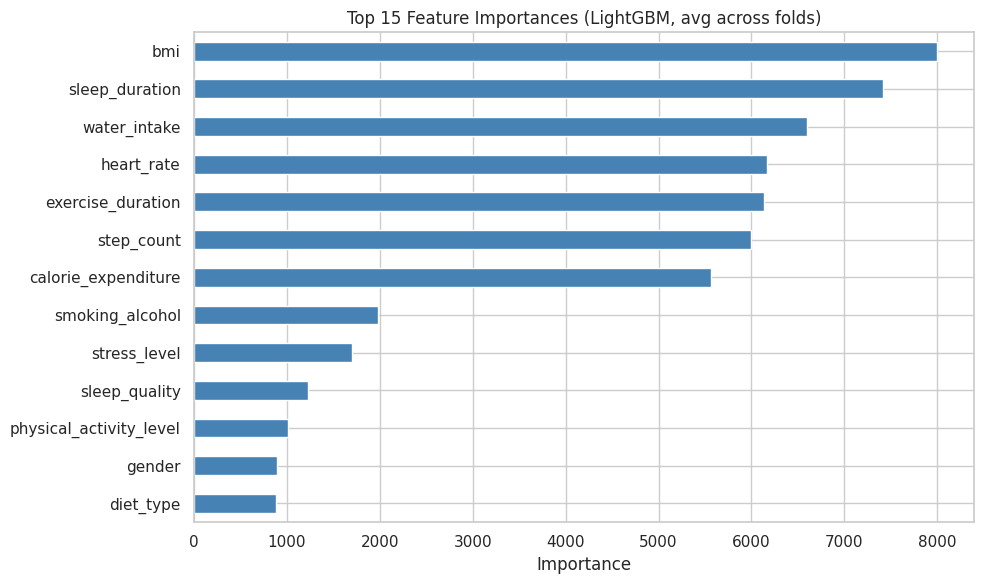

In [12]:
# ── Feature importance from LightGBM ─────────────────────────────────
fi_avg = feature_importances.mean(axis=1).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
fi_avg.head(15).plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Feature Importances (LightGBM, avg across folds)")
ax.set_xlabel("Importance")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

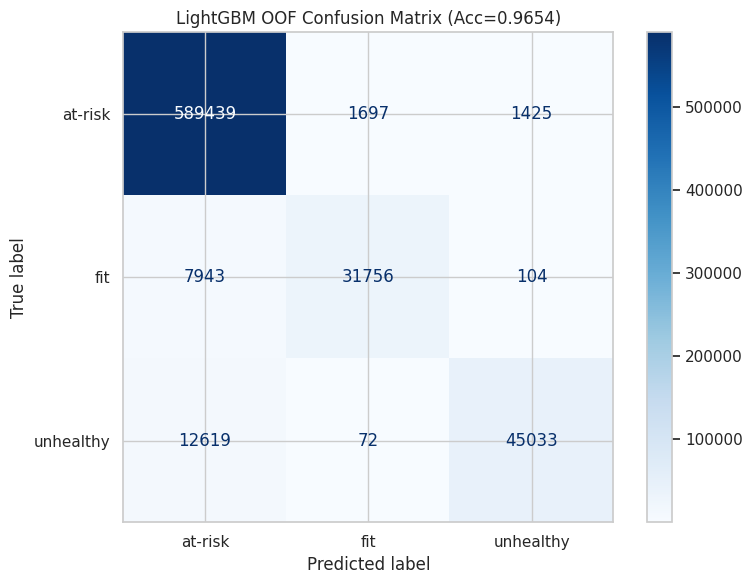


Classification Report (OOF):
              precision    recall  f1-score   support

     at-risk       0.97      0.99      0.98    592561
         fit       0.95      0.80      0.87     39803
   unhealthy       0.97      0.78      0.86     57724

    accuracy                           0.97    690088
   macro avg       0.96      0.86      0.90    690088
weighted avg       0.97      0.97      0.96    690088



In [13]:
# ── Confusion matrix (OOF) ───────────────────────────────────────────
cm = confusion_matrix(y, oof_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_ORDER)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title(f"LightGBM OOF Confusion Matrix (Acc={oof_acc:.4f})")
plt.tight_layout()
plt.show()

print("\nClassification Report (OOF):")
print(classification_report(y, oof_preds, target_names=CLASS_ORDER))

## 7) Submission

In [14]:
# Final submission uses LightGBM averaged test predictions
test_preds_class = np.argmax(test_preds_proba, axis=1)
test_labels = le_target.inverse_transform(test_preds_class)

submission = sample_sub.copy()
submission[TARGET] = test_labels

# Validate submission format
assert submission.shape[0] == sample_sub.shape[0], "Row count mismatch!"
assert list(submission.columns) == list(sample_sub.columns), "Column mismatch!"
assert submission[TARGET].isna().sum() == 0, "NaN predictions!"

# Save: submission.csv is the primary file Kaggle reads from /kaggle/working/
submission.to_csv(os.path.join(output_dir, "submission.csv"), index=False)

print("=" * 60)
print("SUBMISSION READY")
print(f"  File: {output_dir}/submission.csv")
print(f"  Shape: {submission.shape}")
print(f"  LightGBM OOF Accuracy: {oof_acc:.5f}")
print(f"  Baseline LR Accuracy:  {lr_scores.mean():.5f}")
print(f"  Improvement: +{oof_acc - lr_scores.mean():.5f}")
print("=" * 60)
print("\nPrediction distribution:")
print(submission[TARGET].value_counts())
print("\nSample rows:")
display(submission.head(10))

SUBMISSION READY
  File: /kaggle/working/submission.csv
  Shape: (295753, 2)
  LightGBM OOF Accuracy: 0.96542
  Baseline LR Accuracy:  0.90567
  Improvement: +0.05975

Prediction distribution:
health_condition
at-risk      262117
unhealthy     19580
fit           14056
Name: count, dtype: int64

Sample rows:


,id,health_condition
0,690088,unhealthy
1,690089,at-risk
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy
5,690093,at-risk
6,690094,at-risk
7,690095,at-risk
8,690096,at-risk
9,690097,at-risk
